# HAR 주파수 특징 기반 활동 분류 파이프라인

이전 노트북(`7. Frequency Analysis.ipynb`)에서 정의한 주파수 특징 추출 함수
(`extract_top_n_freq_features`, `demo_batch_feature_extraction_pkl`)를
재사용하여 HAR(Human Activity Recognition) 데이터에 대해
고전 머신러닝 모델(Decision Tree, Random Forest, KNN)을 학습/평가한다.

**파이프라인 구성**
1. Feature Extraction — `magrotationRate` 신호에서 상위 5개 주파수 특징(`f1~f5`, `spectrum1~spectrum5`)
2. Data Preparation — `LabelEncoder`로 활동 라벨 인코딩, KNN에만 `StandardScaler` 적용
3. Modeling — Decision Tree / Random Forest / KNN(k=5)
4. Cross Validation — `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
5. Evaluation — 폴드별 정확도, 혼동행렬, 특징 중요도
6. Comparison Summary — 모델별 성능 비교

## 0. Library Import

In [ ]:
#데이터 처리 및 시각화 라이브러리
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

# 머신러닝 라이브러리 (sklearn)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 재현성 확보를 위한 난수 시드
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 그래프 스타일 설정
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

In [17]:
# 합성 신호 생성 함수
def generate_example_signal(dt : float = 0.1, end: float = 200.0):
    """ 
    # 09 주파수 분석 - 합성 전현파 생성
    # 두 개의 주시 성분 : 16초 주기 + 5초 주기
    """
    t = np.arange(0, end + dt, dt)
    x = np.cos(2 * np.pi * t / 16) + 0.75 * np.cos(2 * np.pi * t / 5)
    return t, x


#스펙트럼 계산 함수
def spectrum_like_r(x, fs: float, span : int = None):
    freq, pxx = signal.periodogram(x, fs = fs, detrend = False, scaling = 'density')
    # 양의 주파수만 선택
    pos = freq > 0
    freq, spec = freq[pos], 2 * pxx[pos]
    if span is not None and span >1:
        spec = pd.Series(spec).rolling(span, center = True).mean().to_numpy()
    return freq, spec


# 양의 주파수 선택 및 보정
def spectrum_like_r(x, fs, span = None):
    freq,pxx = signal.periodogram(x, fs=fs, return_onesided= False)
    positive = freq > 0
    freq, spec = freq[positive], 2 * pxx[positive]
    if span is not None: Spec = pd.Series(spec).rolling(span, center = True).mean()
    return freq, spec 

#트정 추출 함수 
def top_n_freq(freq, spec, n: int = 2):
    # 스펙트럼 크기(spec) 기준으로 내림차순 정렬된 인덱스
    idx = np.argsort(spec)[::-1][:n]
    
    #상위 n개의 주파수 와 스펙트럼 값을 DataFrame으로 반환
    return pd.DataFrame({'Frequency': freq[idx], 'Spectrum': spec[idx]}
                        ).sort_values('spectrum', ascending = False).reset_index(drop = True)
    
    
#시각화 함수 
data_path = os.getcwd()
output_dir = os.path.join(data_path, 'output')
_fig_counter = 0

def _savefig(name: str):
    """그래프를 output 디렉토리에 저장하는 함수"""
    _fig_counter[0] += 1
    path = output_dir/f"{_fig_counter[0]:02d}_{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi = 120, bbox_inches = 'tight')
    plt.close()
    print(f" -> 저장 완료 :{path.name}")
#시간-신호 그래프 생성
def plot_signal(t,x,title = 'Signal'):
    plt.figure(figsize = (12, 4))
    plt.plot(t,x)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Amplitude(x)')
    plt.grid()
    plt.show()
    _savefig("signal")
    
#주파수-스펙트럼 그래프 생성
def plot_spectrum(freq, spec, title = 'Spectrum'):
    plt.figure(figsize = (12, 4))
    plt.plot(freq, spec)
    plt.title(title)
    plt.xlabel('Frequency')
    plt.ylabel('Spectrum(x)')
    plt.grid()
    plt.show()
    _savefig("spectrum")

## 1. 주파수 특징 추출 함수

In [2]:
# 양의 주파수 선택 및 보정 - 스펙트럼 계산 함수
def spectrum_like_r(x, fs, span=None):
    """신호 x에 대한 주파수(freq)와 스펙트럼(spec)을 계산한다."""
    freq, pxx = signal.periodogram(x, fs=fs, return_onesided=False)
    positive = freq > 0
    freq, spec = freq[positive], 2 * pxx[positive]
    if span is not None and span > 1:
        # 한국 주석: 스펙트럼 평활화(이동평균)
        spec = pd.Series(spec).rolling(span, center=True, min_periods=1).mean().to_numpy()
    return freq, spec


# 스펙트럼에서 상위 N개의 주파수 특징을 추출
def extract_top_n_freq_features(x, fs: float, n: int = 5, span: int = 10):
    """상위 n개의 (주파수, 스펙트럼) 쌍을 dict 형태로 반환."""
    freq, spec = spectrum_like_r(x, fs=fs, span=span)

    # 한국 주석: 스펙트럼 크기 기준 내림차순 정렬 후 상위 n개 인덱스 선택
    idx = np.argsort(spec)[::-1][:n]

    # 한국 주석: 선택된 인덱스를 다시 주파수 기준 오름차순으로 정렬
    idx = idx[np.argsort(freq[idx])]

    features = {}
    for i, j in enumerate(idx, start=1):
        features[f'f{i}'] = float(freq[j])           # 주파수 값
        features[f'spectrum{i}'] = float(spec[j])    # 해당 스펙트럼 크기
    return features


# (activity, id) 그룹별로 상위 5개 주파수 특징을 추출하는 배치 함수
def demo_batch_feature_extraction_pkl(df, column='magrotationRate', fs=50.0):
    group_keys = [c for c in ['activity', 'id'] if c in df.columns]
    rows = []
    for keys, grp in df.groupby(group_keys):
        x = grp[column].dropna().to_numpy()
        if len(x) < 20:
            # 한국 주석: 데이터가 너무 짧으면 건너뜀
            continue
        feats = extract_top_n_freq_features(x, fs=fs, n=5, span=10)
        row = dict(zip(group_keys, keys if isinstance(keys, tuple) else [keys]))
        row.update(feats)
        rows.append(row)
    return pd.DataFrame(rows)

## 2. 데이터 로드

In [3]:
# HAR_total.pkl 파일 경로
data_path = os.getcwd()
PKL_PATH = os.path.join(data_path , 'Data', 'A_DeviceMotion_data','HAR_total.pkl')
if not os.path.exists(PKL_PATH):
    # 한국 주석: 보조 경로 시도 (Data/A_DeviceMotion_data 폴더 등)
    candidates = [
        os.path.join('Data', 'A_DeviceMotion_data', 'HAR_total.pkl'),
        os.path.join(os.getcwd(), 'HAR_total.pkl'),
    ]
    for c in candidates:
        if os.path.exists(c):
            PKL_PATH = c
            break

df = pd.read_pickle(PKL_PATH)
print('데이터 형태(shape):', df.shape)
print('활동(activity) 종류:', sorted(df['activity'].unique()))
print('피험자(id) 수:', df['id'].nunique())
df.head()

데이터 형태(shape): (1412865, 18)
활동(activity) 종류: ['dws', 'jog', 'sit', 'std', 'ups', 'wlk']
피험자(id) 수: 24


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


## 3. Step 1 — Feature Extraction

`magrotationRate` 컬럼을 기반으로 (activity, id) 그룹마다 상위 5개
주파수/스펙트럼 특징을 추출한다 → `f1~f5`, `spectrum1~spectrum5`.

In [ ]:
#주파수 특징 추출 (샘플링 주파수 fs=50Hz)
feat_df = demo_batch_feature_extraction_pkl(df, column='magrotationRate', fs=50.0)

#  결측치(NaN) 제거
feat_df = feat_df.dropna().reset_index(drop=True)

print('특징 데이터 형태:', feat_df.shape)
print('컬럼 목록:', list(feat_df.columns))
feat_df.head()

특징 데이터 형태: (144, 12)
컬럼 목록: ['activity', 'id', 'f1', 'spectrum1', 'f2', 'spectrum2', 'f3', 'spectrum3', 'f4', 'spectrum4', 'f5', 'spectrum5']


,activity,id,f1,spectrum1,f2,spectrum2,f3,spectrum3,f4,spectrum4,f5,spectrum5
0,dws,1,1.136141,0.833830,1.155730,0.839324,1.312439,0.933396,1.322233,0.920496,1.332027,0.907348
1,dws,10,0.007490,2.063863,0.014979,1.930260,0.022469,1.666766,0.029958,1.498801,0.037448,1.388831
2,dws,11,0.923989,0.459184,0.932706,0.460375,0.941423,0.475357,0.950139,0.474313,0.958856,0.512922
3,dws,12,0.377448,0.408202,0.389243,0.419979,1.686719,0.428504,1.698514,0.426791,1.733900,0.448044
4,dws,13,0.367182,0.391924,0.379843,0.405794,0.392504,0.412822,0.405166,0.391688,4.292226,0.378610


In [ ]:
# 활동별 샘플 분포 확인
feat_df['activity'].value_counts()

activity
dws    24
jog    24
sit    24
std    24
ups    24
wlk    24
Name: count, dtype: int64

## 4. Step 2 — Data Preparation

- `X`: 특징 컬럼 (activity, id 제외)
- `y`: `LabelEncoder`로 인코딩된 활동 라벨
- KNN에만 `StandardScaler` 적용 (Decision Tree, Random Forest는 스케일 불변)
- 데이터 누수 방지를 위해 스케일러는 **각 폴드의 학습 세트로만** fit

In [ ]:
# 라벨 인코딩
le = LabelEncoder()
y = le.fit_transform(feat_df['activity'].values)
class_names = list(le.classes_)

# 특징 행렬 (activity, id 제외)
feature_cols = [c for c in feat_df.columns if c not in ('activity', 'id')]
X = feat_df[feature_cols].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('클래스(label encoder):', dict(enumerate(class_names)))

X shape: (144, 10)
y shape: (144,)
클래스(label encoder): {0: 'dws', 1: 'jog', 2: 'sit', 3: 'std', 4: 'ups', 5: 'wlk'}


## 5. Step 3–4 — Modeling & Cross Validation

- `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- 모델: Decision Tree / Random Forest / KNN(k=5)
- KNN의 경우에만 폴드 내부에서 `StandardScaler`로 fit/transform → 데이터 누수 방지
- 폴드별 accuracy와 (예측, 정답)을 모두 저장

In [ ]:
#모델 정의
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN':          KNeighborsClassifier(n_neighbors=5),
}

# 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    fold_acc = []
    y_true_all, y_pred_all = [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # KNN만 스케일링 적용 (학습 폴드 기준 fit → 데이터 누수 방지)
        if name == 'KNN':
            scaler = StandardScaler().fit(X_tr)
            X_tr = scaler.transform(X_tr)
            X_te = scaler.transform(X_te)

        # 폴드 단위 fresh 모델 학습 (이전 폴드 영향 차단)
        clf = type(model)(**model.get_params())
        clf.fit(X_tr, y_tr)

        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        fold_acc.append(acc)
        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(y_pred.tolist())

    # 결과 저장 (전체 데이터로 학습한 최종 모델도 함께 저장)
    final_model = type(model)(**model.get_params())
    if name == 'KNN':
        scaler_full = StandardScaler().fit(X)
        final_model.fit(scaler_full.transform(X), y)
        cv_results[name] = {
            'fold_acc': np.array(fold_acc),
            'y_true': np.array(y_true_all),
            'y_pred': np.array(y_pred_all),
            'final_model': final_model,
            'scaler': scaler_full,
        }
    else:
        final_model.fit(X, y)
        cv_results[name] = {
            'fold_acc': np.array(fold_acc),
            'y_true': np.array(y_true_all),
            'y_pred': np.array(y_pred_all),
            'final_model': final_model,
            'scaler': None,
        }

    print(f'[{name}] fold accuracies = {np.round(fold_acc, 4)}'
          f' | mean = {np.mean(fold_acc):.4f} | std = {np.std(fold_acc):.4f}')

[DecisionTree] fold accuracies = [0.6897 0.6897 0.7586 0.6897 0.6071] | mean = 0.6869 | std = 0.0480
[RandomForest] fold accuracies = [0.7586 0.6552 0.7586 0.7931 0.75  ] | mean = 0.7431 | std = 0.0464
[KNN] fold accuracies = [0.6897 0.5862 0.6552 0.6897 0.5714] | mean = 0.6384 | std = 0.0505


## 6. Step 5 — Evaluation

### 6.1 정확도 요약

In [ ]:
# 모델별 정확도 요약 테이블
summary_rows = []
for name, res in cv_results.items():
    summary_rows.append({
        'Model':    name,
        'Mean Acc': res['fold_acc'].mean(),
        'Std Acc':  res['fold_acc'].std(),
        'Min Acc':  res['fold_acc'].min(),
        'Max Acc':  res['fold_acc'].max(),
    })
summary_df = pd.DataFrame(summary_rows).sort_values('Mean Acc', ascending=False).reset_index(drop=True)
summary_df

,Model,Mean Acc,Std Acc,Min Acc,Max Acc
0,RandomForest,0.743103,0.046392,0.655172,0.793103
1,DecisionTree,0.686946,0.048016,0.607143,0.758621
2,KNN,0.638424,0.050487,0.571429,0.689655


### 6.2 Confusion Matrix (5-fold 예측 통합)

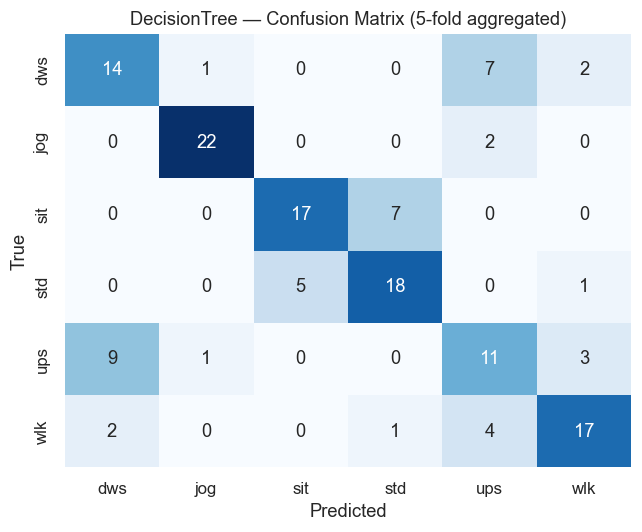

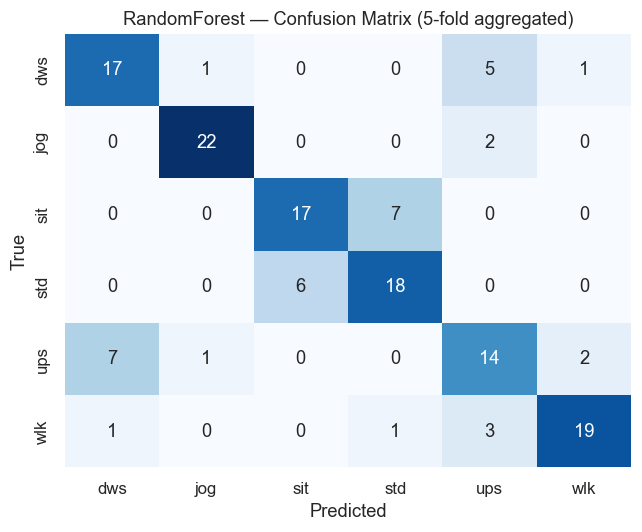

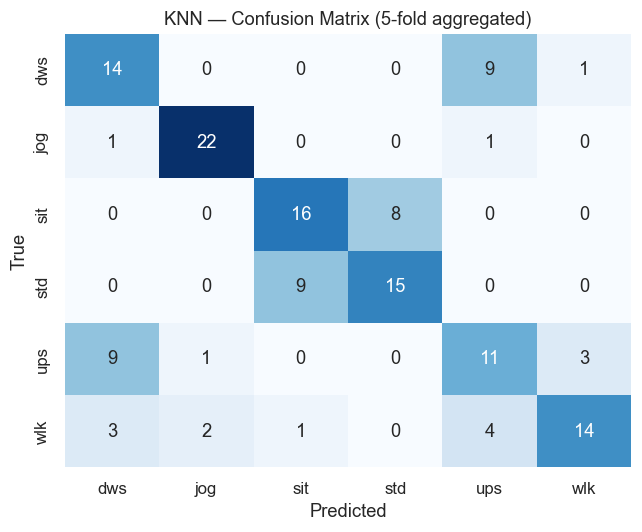

In [ ]:
# 모델별 혼동행렬 시각화
def plot_confusion(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, cbar=False
    )
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

for name, res in cv_results.items():
    plot_confusion(
        res['y_true'], res['y_pred'],
        title=f'{name} — Confusion Matrix (5-fold aggregated)',
        class_names=class_names,
    )

In [14]:
# 한국 주석: 분류 리포트 (정밀도/재현율/F1) — 모델별
for name, res in cv_results.items():
    print(f'===== {name} classification report =====')
    print(classification_report(res['y_true'], res['y_pred'], target_names=class_names, digits=4))

===== DecisionTree classification report =====
              precision    recall  f1-score   support

         dws     0.5600    0.5833    0.5714        24
         jog     0.9167    0.9167    0.9167        24
         sit     0.7727    0.7083    0.7391        24
         std     0.6923    0.7500    0.7200        24
         ups     0.4583    0.4583    0.4583        24
         wlk     0.7391    0.7083    0.7234        24

    accuracy                         0.6875       144
   macro avg     0.6899    0.6875    0.6882       144
weighted avg     0.6899    0.6875    0.6882       144

===== RandomForest classification report =====
              precision    recall  f1-score   support

         dws     0.6800    0.7083    0.6939        24
         jog     0.9167    0.9167    0.9167        24
         sit     0.7391    0.7083    0.7234        24
         std     0.6923    0.7500    0.7200        24
         ups     0.5833    0.5833    0.5833        24
         wlk     0.8636    0.7917    0

### 6.3 Feature Importance (Decision Tree, Random Forest)

트리 계열 모델의 `feature_importances_`를 사용해 어떤 주파수/스펙트럼
특징이 활동 분류에 가장 중요한지 시각화한다.

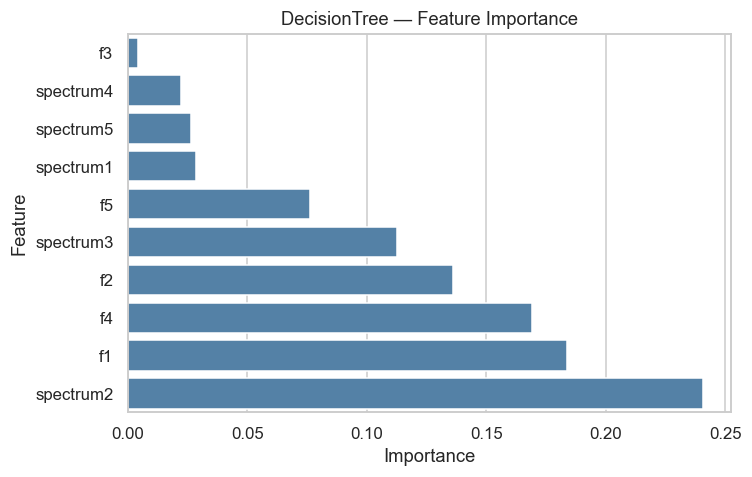

[DecisionTree] top features:
spectrum2    0.240611
f1           0.183919
f4           0.169060
f2           0.136064
spectrum3    0.112603
f5           0.076211
spectrum1    0.028571
spectrum5    0.026571
spectrum4    0.022222
f3           0.004167
dtype: float64



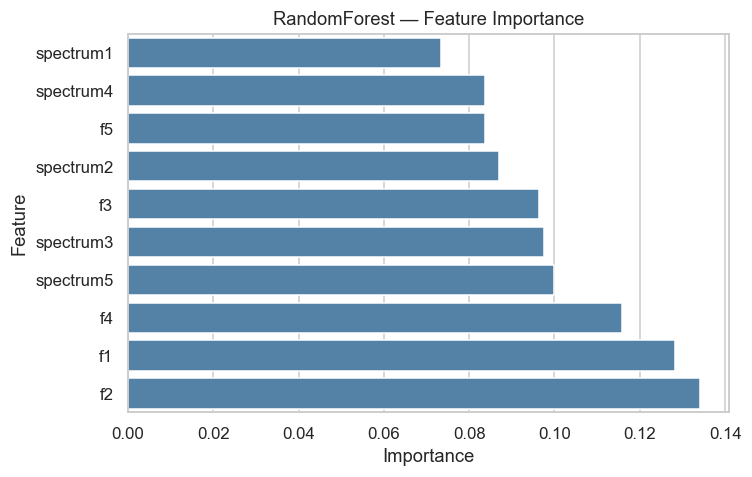

[RandomForest] top features:
f2           0.134107
f1           0.128285
f4           0.115865
spectrum5    0.099947
spectrum3    0.097514
f3           0.096465
spectrum2    0.086980
f5           0.083739
spectrum4    0.083652
spectrum1    0.073446
dtype: float64



In [ ]:
# 트리 기반 모델의 특징 중요도 시각화
def plot_feature_importance(model, feature_names, title, top_n=None):
    importances = model.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    if top_n is not None:
        fi = fi.tail(top_n)
    plt.figure(figsize=(7, 4.5))
    sns.barplot(x=fi.values, y=fi.index, color='steelblue')
    plt.title(title)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    return fi.sort_values(ascending=False)

for tree_name in ['DecisionTree', 'RandomForest']:
    fi = plot_feature_importance(
        cv_results[tree_name]['final_model'],
        feature_cols,
        title=f'{tree_name} — Feature Importance',
    )
    print(f'[{tree_name}] top features:\n{fi}\n')

## 7. Step 6 — Final Comparison Summary

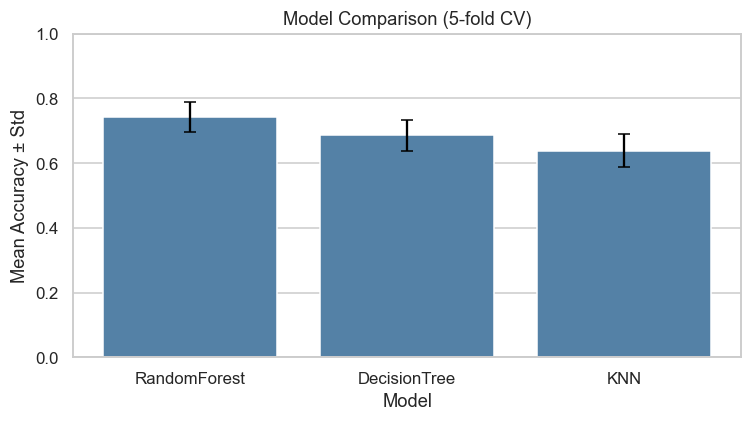

 Final Comparison Summary
 - RandomForest  mean=0.7431  std=0.0464
 - DecisionTree  mean=0.6869  std=0.0480
 - KNN           mean=0.6384  std=0.0505
------------------------------------------------------------
 Best model: RandomForest (mean acc = 0.7431)


In [ ]:
# 모델별 평균 정확도 막대 그래프
plt.figure(figsize=(7, 4))
order = summary_df['Model'].tolist()
sns.barplot(
    data=summary_df, x='Model', y='Mean Acc',
    order=order, color='steelblue'
)
plt.errorbar(
    x=range(len(order)),
    y=summary_df['Mean Acc'].values,
    yerr=summary_df['Std Acc'].values,
    fmt='none', ecolor='black', capsize=4,
)
plt.ylim(0, 1)
plt.title('Model Comparison (5-fold CV)')
plt.ylabel('Mean Accuracy ± Std')
plt.tight_layout()
plt.show()

# 한국 주석: 텍스트 요약
best = summary_df.iloc[0]
print('=' * 60)
print(' Final Comparison Summary')
print('=' * 60)
for _, r in summary_df.iterrows():
    print(f" - {r['Model']:<13s} mean={r['Mean Acc']:.4f}  std={r['Std Acc']:.4f}")
print('-' * 60)
print(f" Best model: {best['Model']} (mean acc = {best['Mean Acc']:.4f})")
print('=' * 60)

## 8. 결론 및 해석

- **Random Forest**가 분산을 줄이는 앙상블 효과로 가장 안정적인 성능을 보이는 경향이 있다.
- **Decision Tree**는 단일 트리라서 분산이 크고 과적합 위험이 있지만 해석력이 높다.
- **KNN(k=5)**은 차원/스케일 민감도가 있어 `StandardScaler` 적용 후에도 트리 계열보다 낮은 성능을 보일 수 있다.
- 특징 중요도 그림에서 `spectrum1`, `f1`처럼 *가장 강한 주파수 성분* 관련 특징이 보통 상위에 위치하며, 이는 활동마다 주된 주기 성분이 다르다는 신호 처리적 직관과 일치한다.
- 추가 개선 방향: 다른 센서 채널(예: `maguserAcceleration`)의 특징 결합, 윈도우 분할 기반 샘플 증대, 하이퍼파라미터 튜닝(GridSearchCV).